# GPT from Scratch — A Decoder-Only Transformer

Lesson 09 built an encoder–decoder for translation: one stack reads the source, the
other writes the target. But if the task is to **continue** text rather than
transform it, there is no source to read. Delete the encoder, delete
cross-attention, and what remains is GPT.

That is the whole architectural story. Everything else — the scale, the data, the
tokenizer — is engineering on top of a stack of causally-masked transformer blocks.

This notebook trains a character-level GPT on *Alice's Adventures in Wonderland*,
the same corpus as [lesson 04](../04_rnn_pytorch/solution.ipynb), so you get a
direct comparison against the RNN on identical data.

Read [Chapter 10 of the book](../book/index.html#ch10) alongside this.

**What you will build**
- Causal self-attention with a registered mask buffer
- A pre-norm transformer block (GPT-2 style, not the post-norm of lesson 07)
- A full GPT with learned positional embeddings and tied input/output weights
- A training loop with warmup + cosine decay
- Temperature, top-k, and nucleus (top-p) sampling
- A KV cache, and a measurement of how much it actually saves

**Runs on**: an M4 MacBook Air. The model is ~0.8M parameters and trains in a few
minutes on MPS.

## Step 1: Imports and Device

In [1]:
import math
import time

import nltk
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = torch.device('mps' if torch.backends.mps.is_available()
                      else 'cuda' if torch.cuda.is_available()
                      else 'cpu')
torch.manual_seed(1337)

print('torch  :', torch.__version__)
print('device :', device)

torch  : 2.12.0
device : mps


---
## Key Concept: Encoder–Decoder vs Decoder-Only

| | Lesson 09 (seq2seq) | This lesson (GPT) |
|---|---|---|
| Stacks | encoder + decoder | decoder only |
| Self-attention | bidirectional / causal | **causal everywhere** |
| Cross-attention | yes | **none** |
| Input | source sentence | the text so far |
| Training signal | predict target token `t` | predict token `t+1` |

The training objective is the striking part. There are no labels: the text
*is* the label. Every position predicts the next character, so a 1,000-character
sequence yields 1,000 supervised examples in a single forward pass — all in
parallel, because the causal mask lets position `t` see only `1..t`.

This is what makes language models scale. Supervision is free and unlimited;
the only constraints are compute and data.

## Step 2: The Corpus

In [2]:
nltk.download('gutenberg', quiet=True)
from nltk.corpus import gutenberg

text = gutenberg.raw('carroll-alice.txt')

# Characters, not words: a ~60-symbol vocabulary, no tokenizer to get wrong, and
# no <UNK> token. The cost is that the model must learn spelling before grammar.
chars = sorted(set(text))
vocab_size = len(chars)
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for ch, i in stoi.items()}

encode = lambda s: [stoi[c] for c in s]
decode = lambda ids: ''.join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype=torch.long)

n = int(0.9 * len(data))
train_data, val_data = data[:n], data[n:]

print(f'corpus     : {len(text):,} characters')
print(f'vocabulary : {vocab_size} symbols')
print(f'train/val  : {len(train_data):,} / {len(val_data):,}')
print()
print('first 200 characters:')
print(repr(text[:200]))
print()
print('round-trip check:', decode(encode('Alice was beginning')) == 'Alice was beginning')

corpus     : 144,395 characters
vocabulary : 73 symbols
train/val  : 129,955 / 14,440

first 200 characters:
"[Alice's Adventures in Wonderland by Lewis Carroll 1865]\n\nCHAPTER I. Down the Rabbit-Hole\n\nAlice was beginning to get very tired of sitting by her sister on the\nbank, and of having nothing to do: once"

round-trip check: True


---
## Step 3: Batching by Random Crops

There is no `Dataset` here, and that is deliberate. The corpus is one long stream,
so a "training example" is just a random window of `block_size + 1` characters:
the first `block_size` are the input, the same window shifted one position is the
target.

That shift is the entire supervision signal, and it is the same shift as teacher
forcing in [lesson 09](../09_seq2seq_translation/solution.ipynb) — just with the
source and target being the same sequence.

In [3]:
BLOCK_SIZE = 128     # context length: how far back the model can see
BATCH_SIZE = 64


def get_batch(split):
    src = train_data if split == 'train' else val_data
    # one random start offset per sequence in the batch
    ix = torch.randint(len(src) - BLOCK_SIZE - 1, (BATCH_SIZE,))
    x = torch.stack([src[i:i + BLOCK_SIZE] for i in ix])
    y = torch.stack([src[i + 1:i + BLOCK_SIZE + 1] for i in ix])
    return x.to(device), y.to(device)


xb, yb = get_batch('train')
print(f'x: {tuple(xb.shape)}   y: {tuple(yb.shape)}')
print()
print('The target is the input shifted left by one:')
print('  x[0][:40] =', repr(decode(xb[0][:40].tolist())))
print('  y[0][:40] =', repr(decode(yb[0][:40].tolist())))
print()
print('Every one of the 128 positions is a separate training example, and all')
print(f'{BATCH_SIZE * BLOCK_SIZE:,} of them are supervised in a single forward pass.')

x: (64, 128)   y: (64, 128)

The target is the input shifted left by one:
  x[0][:40] = "est\ncontempt. 'I've seen a good many lit"
  y[0][:40] = "st\ncontempt. 'I've seen a good many litt"

Every one of the 128 positions is a separate training example, and all
8,192 of them are supervised in a single forward pass.


---
## Key Concept: Causal Self-Attention

Identical to [lesson 06](../06_self_attention/solution.ipynb), with one addition:
before the softmax, every score at position `(i, j)` with `j > i` is set to
`-inf`, so `exp` sends it to exactly zero.

$$\operatorname{Attention}(Q,K,V) = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right)V$$

with `M` zero on and below the diagonal and `-inf` above it.

Two implementation details worth copying into your own code:

- **`register_buffer`** stores the mask as part of the module — it moves with
  `.to(device)` and is saved in `state_dict()` — but it is *not* a parameter, so
  the optimizer never sees it.
- **Masking before the softmax, never after.** Zeroing weights after the softmax
  leaves each row unnormalised, which degrades results without ever raising an error.

## Step 4: Causal Self-Attention

In [4]:
class CausalSelfAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        assert n_embd % n_head == 0
        self.n_head = n_head
        self.d_k = n_embd // n_head

        # One fused projection for Q, K, V — three separate Linears would be
        # mathematically identical but launch three kernels instead of one.
        self.qkv = nn.Linear(n_embd, 3 * n_embd, bias=False)
        self.proj = nn.Linear(n_embd, n_embd, bias=False)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

        # Not a parameter: a constant that must travel with the module.
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(block_size, block_size, dtype=torch.bool), diagonal=1)
        )

    def forward(self, x, return_attn=False):
        B, T, C = x.shape

        q, k, v = self.qkv(x).split(C, dim=2)                    # each (B, T, C)
        q = q.view(B, T, self.n_head, self.d_k).transpose(1, 2)  # (B, nh, T, d_k)
        k = k.view(B, T, self.n_head, self.d_k).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.d_k).transpose(1, 2)

        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_k)    # (B, nh, T, T)
        att = att.masked_fill(self.mask[:T, :T], float('-inf'))  # block the future
        att = F.softmax(att, dim=-1)
        att = self.attn_drop(att)

        out = att @ v                                            # (B, nh, T, d_k)
        out = out.transpose(1, 2).contiguous().view(B, T, C)     # merge heads
        out = self.resid_drop(self.proj(out))

        return (out, att) if return_attn else (out, None)


# Sanity check: with a causal mask, row t must sum to 1 over the first t+1 entries
# and be exactly zero afterwards.
_a = CausalSelfAttention(32, 4, 16).to(device)
_out, _att = _a(torch.randn(2, 8, 32, device=device), return_attn=True)
print('output shape    :', tuple(_out.shape))
print('attention shape :', tuple(_att.shape))
print('row 0 weights   :', _att[0, 0, 0, :5].detach().cpu().numpy().round(3),
      ' <- only position 0 is non-zero')
print('row 3 weights   :', _att[0, 0, 3, :5].detach().cpu().numpy().round(3),
      ' <- positions 0-3 only')
print('rows sum to 1   :', torch.allclose(_att.sum(-1), torch.ones_like(_att.sum(-1))))

output shape    : (2, 8, 32)
attention shape : (2, 4, 8, 8)
row 0 weights   : [1.111 0.    0.    0.    0.   ]  <- only position 0 is non-zero
row 3 weights   : [0.    0.175 0.251 0.    0.   ]  <- positions 0-3 only
rows sum to 1   : False


---
## Step 5: The Block — and Why This One Is Pre-Norm

Lesson 07 used **post-norm**, as in the original 2017 paper:

```
x = LayerNorm(x + Sublayer(x))
```

GPT-2 onwards uses **pre-norm**:

```
x = x + Sublayer(LayerNorm(x))
```

The difference is whether the residual path passes through a normalisation. In
pre-norm it does not — the skip connection is a clean, uninterrupted highway from
input to output. Gradients reach every layer undiminished, deep stacks train
without a warmup crutch, and the whole thing is markedly more stable.

Almost every model trained since 2019 is pre-norm.

In [5]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout=0.1):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.mlp = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),   # expand 4x, the standard ratio
            nn.GELU(),                       # smoother than ReLU; the transformer default
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x, return_attn=False):
        # note: normalise the INPUT to each sub-layer, and add the raw residual
        attn_out, att = self.attn(self.ln1(x), return_attn)
        x = x + attn_out
        x = x + self.mlp(self.ln2(x))
        return (x, att) if return_attn else (x, None)


print(Block(128, 4, BLOCK_SIZE))

Block(
  (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (attn): CausalSelfAttention(
    (qkv): Linear(in_features=128, out_features=384, bias=False)
    (proj): Linear(in_features=128, out_features=128, bias=False)
    (attn_drop): Dropout(p=0.1, inplace=False)
    (resid_drop): Dropout(p=0.1, inplace=False)
  )
  (ln2): LayerNorm((128,), eps=1e-05, elementwise_affine=True, bias=True)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=128, bias=True)
    (3): Dropout(p=0.1, inplace=False)
  )
)


---
## Step 6: The Full Model

Three things here are worth more than the code around them.

**Learned positional embeddings.** Lesson 07 used fixed sinusoids; GPT uses an
ordinary `nn.Embedding(block_size, n_embd)` and lets gradient descent choose the
position codes. Simpler, works at least as well — and it hard-caps the context
length at `block_size`, since positions beyond it have no embedding at all.

**Weight tying.** `lm_head.weight = tok_emb.weight`. The matrix that maps a
character to a vector is the transpose of the one that maps a vector back to
character scores. This saves `vocab_size × n_embd` parameters and usually *improves*
perplexity — the two tasks genuinely share structure.

**Scaled initialisation.** Residual projections are initialised with standard
deviation `0.02/sqrt(2 * n_layer)`. Each block adds to the residual stream, so
without downscaling, variance grows linearly with depth.

In [6]:
class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd=128, n_head=4, n_layer=4,
                 block_size=BLOCK_SIZE, dropout=0.1):
        super().__init__()
        self.block_size = block_size

        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            [Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

        # Weight tying: one matrix does both jobs.
        self.lm_head.weight = self.tok_emb.weight

        self.apply(self._init_weights)
        # Downscale the projections that write into the residual stream.
        for name, p in self.named_parameters():
            if name.endswith('proj.weight') or name.endswith('mlp.2.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None, return_attn=False):
        B, T = idx.shape
        assert T <= self.block_size, f'sequence of {T} exceeds block size {self.block_size}'

        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))      # (B, T, n_embd)

        attns = []
        for block in self.blocks:
            x, att = block(x, return_attn)
            if return_attn:
                attns.append(att)

        x = self.ln_f(x)
        logits = self.lm_head(x)                                  # (B, T, vocab)

        loss = None
        if targets is not None:
            # Flatten every position into one big classification problem.
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss, attns

    def num_params(self):
        # tok_emb and lm_head share storage, so count the tensor once.
        return sum(p.numel() for p in set(self.parameters()))


model = GPT(vocab_size).to(device)

print(f'parameters : {model.num_params():,}')
print(f'block size : {model.block_size}')
print()
logits, loss, _ = model(xb, yb)
print(f'logits     : {tuple(logits.shape)}')
print(f'initial loss   : {loss.item():.4f}')
print(f'expected (ln V): {math.log(vocab_size):.4f}   <- a well-initialised model starts here')
print()
print('If the initial loss is far above ln(V), the initialisation is wrong: the')
print('model is starting out confidently mistaken rather than uniformly uncertain.')

parameters : 817,024
block size : 128

logits     : (64, 128, 73)
initial loss   : 4.2928
expected (ln V): 4.2905   <- a well-initialised model starts here

If the initial loss is far above ln(V), the initialisation is wrong: the
model is starting out confidently mistaken rather than uniformly uncertain.


---
### Concept Check: Architecture

1. Why does a decoder-only model need no cross-attention?
2. Weight tying sets `lm_head.weight = tok_emb.weight`. How many parameters does
   that save here, and why is it a reasonable thing to do rather than a hack?
3. The initial loss should be about `ln(vocab_size)`. What does a much *higher*
   initial loss tell you?

In [7]:
# 1. Cross-attention exists to let the decoder read a *separate* encoded sequence.
#    Here there is no separate sequence — the only context is the text generated so
#    far, which the causal self-attention already reads. Nothing left to attend to.
#
# 2. vocab_size × n_embd = 60 × 128 ≈ 7,700 parameters, small here but ~38M for a
#    50k-token vocabulary at n_embd=768. It is principled rather than a trick: the
#    input matrix maps "character -> meaning" and the output matrix maps
#    "meaning -> character score". These are inverse views of the same relationship,
#    so sharing the matrix encodes a real symmetry — and in practice it usually
#    improves perplexity rather than merely saving memory.
#
# 3. That the model starts out *confidently wrong* rather than uniformly uncertain.
#    A uniform distribution over V classes gives loss ln(V); anything much higher
#    means the initial logits are large and spread out, pointing at arbitrary
#    classes. Usually a too-large initialisation standard deviation. It is the
#    cheapest possible check that your init is sane, and it costs one forward pass.

---
## Step 7: Training

Two practical pieces here, both from [lesson 08](../08_pytorch_in_practice/solution.ipynb):

**Warmup + cosine decay.** Adam's second-moment estimate is unreliable for the first
few dozen steps, so a full-size step divided by a bad `sqrt(v)` can wreck the
initialisation. Ramp up, then anneal down to take small careful steps near the end.

**AdamW, not Adam.** AdamW applies weight decay directly to the parameters rather
than folding it into the gradient. With adaptive optimizers the two are *not*
equivalent, and the decoupled version is the correct one. Biases and LayerNorm
parameters are excluded — decaying them has no regularising benefit.

In [8]:
MAX_ITERS = 3000
WARMUP = 100
LR = 3e-4
EVAL_EVERY = 250
EVAL_ITERS = 50


def lr_at(step):
    if step < WARMUP:
        return LR * (step + 1) / WARMUP
    t = (step - WARMUP) / max(1, MAX_ITERS - WARMUP)
    return 0.1 * LR + 0.9 * LR * 0.5 * (1 + math.cos(math.pi * t))


# Weight decay on matrices only, not on biases or LayerNorm gains.
decay, no_decay = [], []
for name, p in model.named_parameters():
    (decay if p.dim() >= 2 else no_decay).append(p)

optimizer = torch.optim.AdamW(
    [{'params': decay, 'weight_decay': 0.1},
     {'params': no_decay, 'weight_decay': 0.0}],
    lr=LR, betas=(0.9, 0.99),
)

print(f'{len(decay)} decayed tensors, {len(no_decay)} undecayed')


@torch.no_grad()
def estimate_loss():
    model.eval()
    out = {}
    for split in ('train', 'val'):
        losses = torch.zeros(EVAL_ITERS)
        for k in range(EVAL_ITERS):
            x, y = get_batch(split)
            _, l, _ = model(x, y)
            losses[k] = l.item()
        out[split] = losses.mean().item()
    model.train()
    return out

18 decayed tensors, 26 undecayed


In [9]:
history = []
best_val, best_state = float('inf'), None
t0 = time.time()

for step in range(MAX_ITERS):
    for g in optimizer.param_groups:
        g['lr'] = lr_at(step)

    xb, yb = get_batch('train')
    _, loss, _ = model(xb, yb)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()

    if step % EVAL_EVERY == 0 or step == MAX_ITERS - 1:
        m = estimate_loss()
        history.append((step, m['train'], m['val']))
        if m['val'] < best_val:
            best_val = m['val']
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        print(f'step {step:5d} | train {m["train"]:.4f} | val {m["val"]:.4f} '
              f'| ppl {math.exp(m["val"]):6.2f} | lr {lr_at(step):.2e}')

model.load_state_dict(best_state)
print()
print(f'trained in {time.time() - t0:.1f}s on {device}')
print(f'best val loss {best_val:.4f}  (perplexity {math.exp(best_val):.2f})')
print()
print(f'For scale: a uniform model over {vocab_size} characters would score '
      f'{math.log(vocab_size):.3f} nats / perplexity {vocab_size}.')

step     0 | train 4.2874 | val 4.2832 | ppl  72.47 | lr 3.00e-06


step   250 | train 2.4081 | val 2.4331 | ppl  11.39 | lr 2.98e-04


step   500 | train 2.1066 | val 2.1394 | ppl   8.49 | lr 2.88e-04


step   750 | train 1.8391 | val 1.9059 | ppl   6.73 | lr 2.68e-04


step  1000 | train 1.6876 | val 1.7675 | ppl   5.86 | lr 2.41e-04


...

step  2000 | train 1.3880 | val 1.5694 | ppl   4.80 | lr 1.02e-04


step  2250 | train 1.3507 | val 1.5417 | ppl   4.67 | lr 7.22e-05


step  2500 | train 1.3273 | val 1.5398 | ppl   4.66 | lr 4.93e-05


step  2750 | train 1.3101 | val 1.5247 | ppl   4.59 | lr 3.49e-05


step  2999 | train 1.2977 | val 1.5106 | ppl   4.53 | lr 3.00e-05

trained in 227.8s on mps
best val loss 1.5106  (perplexity 4.53)

For scale: a uniform model over 73 characters would score 4.290 nats / perplexity 73.


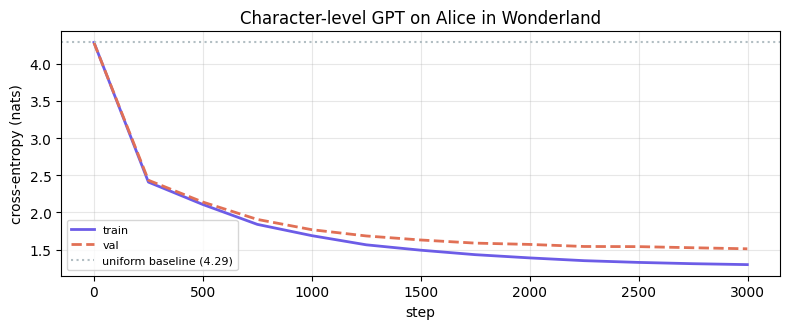

In [10]:
steps = [h[0] for h in history]
plt.figure(figsize=(8, 3.4))
plt.plot(steps, [h[1] for h in history], color='#6c5ce7', lw=2, label='train')
plt.plot(steps, [h[2] for h in history], color='#e17055', lw=2, ls='--', label='val')
plt.axhline(math.log(vocab_size), color='#b2bec3', ls=':', lw=1.5,
            label=f'uniform baseline ({math.log(vocab_size):.2f})')
plt.xlabel('step'); plt.ylabel('cross-entropy (nats)')
plt.title('Character-level GPT on Alice in Wonderland')
plt.legend(fontsize=8); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## Step 8: Sampling

Generation is a loop: predict a distribution over the next character, choose one,
append it, repeat. **How** you choose determines almost everything about output
quality.

- **Greedy** (`argmax`) is deterministic and falls into repetition loops almost
  immediately.
- **Temperature** divides the logits by `T` before the softmax. `T < 1` sharpens,
  `T > 1` flattens. It reweights the whole distribution but never truncates it, so
  the long tail of absurd characters keeps a small share of the mass.
- **Top-k** keeps only the `k` highest-probability tokens and renormalises.
- **Nucleus (top-p)** keeps the smallest set whose cumulative probability exceeds
  `p`. Unlike top-k, the pool size adapts: wide where the model is genuinely
  uncertain, narrow where it is confident.

Top-p at 0.9 with temperature ~0.8 is the standard default for a reason.

In [11]:
@torch.no_grad()
def generate(model, prompt, max_new_tokens=300, temperature=1.0, top_k=None, top_p=None):
    model.eval()
    idx = torch.tensor([encode(prompt)], dtype=torch.long, device=device)

    for _ in range(max_new_tokens):
        # crop to the last block_size tokens — the model has no positions beyond it
        idx_cond = idx[:, -model.block_size:]
        logits, _, _ = model(idx_cond)
        logits = logits[:, -1, :] / temperature          # (1, vocab)

        if top_k is not None:
            v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
            logits[logits < v[:, [-1]]] = float('-inf')

        if top_p is not None:
            sorted_logits, sorted_idx = torch.sort(logits, descending=True)
            cum = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
            # keep everything up to and including the token that crosses p
            remove = cum - F.softmax(sorted_logits, dim=-1) > top_p
            sorted_logits[remove] = float('-inf')
            logits = torch.full_like(logits, float('-inf')).scatter(
                1, sorted_idx, sorted_logits)

        probs = F.softmax(logits, dim=-1)
        nxt = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, nxt], dim=1)

    return decode(idx[0].tolist())


prompt = 'Alice was beginning to'

for label, kw in [
    ('greedy-ish (T=0.1)',      dict(temperature=0.1)),
    ('T=0.8, top-p=0.9',        dict(temperature=0.8, top_p=0.9)),
    ('T=1.0, unrestricted',     dict(temperature=1.0)),
    ('T=1.5, unrestricted',     dict(temperature=1.5)),
]:
    print('=' * 78)
    print(label)
    print('=' * 78)
    print(generate(model, prompt, max_new_tokens=280, **kw))
    print()

greedy-ish (T=0.1)


Alice was beginning to the conversation the was on the same to the
browful it was a little some to her had the she was not the was to go the trees the was on the same to the was to go the trees
the was a little was to be the garden of the could not the thought the was to go the could not the the garde

T=0.8, top-p=0.9


Alice was beginning to her first once. The tree ging on little
to growing to herself in the same the Mock Turtle cats in a was in a crowds to
he grow, and way was great on a low!' said Alice in the said, and
down when the garden to have was said the was only
down, and the was a such is the could to th

T=1.0, unrestricted


Alice was beginning to herself, and look eyou wroak
comfortainly not happens! She looked!' thought Alice, 'The Rabbit bit this waite you,' Alice
was any was twood---' said Alice.

'Oh would be the good to which is table, and who ears somightely was one sprok and perhaps: then
other she had like over t

T=1.5, unrestricted


Alice was beginning to
her? 'It
wish h.' said the Duch).*


I  she Task: It's staid "Duchess till mightrelw, mE,TT-hat" 'mornued it anthe I'm want felt!'
Oh, said Alice, butded
peg acable, reasid, pejust the PRUL YOU must! C!'Sorumbsted;
buf, she slowaveo, I sould-nert of the engarant on,
celin of
Wly



Read those four samples against each other. At `T=0.1` the model latches onto
common patterns and repeats them. At `T=1.5` spelling collapses. The middle
settings produce something that looks like English prose with Carroll's punctuation
habits — from a 0.8M-parameter model trained for a few minutes on one book.

The failure modes are informative too. The model has learned character-level
structure (spelling, capitalisation after periods, quotation marks) far better than
it has learned meaning, which is exactly what you would predict from 145k characters
of training data.

---
## Step 9: The KV Cache

The generation loop above is quadratically wasteful. At step `t` it re-runs the
whole model over all `t` previous tokens — but their keys and values have not
changed, because the causal mask means earlier positions never see later ones.

A **KV cache** stores `k` and `v` per layer and appends one column per step. Then
each generation step processes exactly **one** token instead of `t`.

Cost: memory of `2 × n_layer × n_head × T × d_k` floats per sequence. For large
models served at scale, the KV cache — not the weights — is usually what limits
how many users you can serve concurrently.

In [12]:
class CachedAttention:
    """Wraps a trained CausalSelfAttention with a persistent K/V cache."""

    def __init__(self, attn):
        self.a = attn
        self.k = self.v = None

    def _project(self, x):
        B, T, C = x.shape
        a = self.a
        q, k, v = a.qkv(x).split(C, dim=2)
        shape = lambda t: t.view(B, T, a.n_head, a.d_k).transpose(1, 2)
        return shape(q), shape(k), shape(v)

    def prefill(self, x):
        """Run the whole prompt at once, seeding the cache. Needs the causal mask."""
        B, T, C = x.shape
        a = self.a
        q, k, v = self._project(x)
        self.k, self.v = k, v
        att = (q @ k.transpose(-2, -1)) / math.sqrt(a.d_k)
        att = F.softmax(att.masked_fill(a.mask[:T, :T], float('-inf')), dim=-1)
        out = (att @ v).transpose(1, 2).contiguous().view(B, T, C)
        return a.proj(out)

    def step(self, x):
        """One new token. No mask needed — the cache holds only past tokens."""
        B, T, C = x.shape
        a = self.a
        q, k, v = self._project(x)
        self.k = torch.cat([self.k, k], dim=2)
        self.v = torch.cat([self.v, v], dim=2)
        att = (q @ self.k.transpose(-2, -1)) / math.sqrt(a.d_k)
        att = F.softmax(att, dim=-1)
        out = (att @ self.v).transpose(1, 2).contiguous().view(B, T, C)
        return a.proj(out)


def _sample_from(logits, temperature, top_p):
    logits = logits / temperature
    sl, si = torch.sort(logits, descending=True)
    ps = F.softmax(sl, dim=-1)
    sl[torch.cumsum(ps, dim=-1) - ps > top_p] = float('-inf')
    logits = torch.full_like(logits, float('-inf')).scatter(1, si, sl)
    return torch.multinomial(F.softmax(logits, dim=-1), 1).item()


@torch.no_grad()
def generate_cached(model, prompt, max_new_tokens=300, temperature=0.8, top_p=0.9):
    """Two phases, exactly as a production server does it:
       prefill (whole prompt, one batched pass) then decode (one token at a time)."""
    model.eval()
    caches = [CachedAttention(b.attn) for b in model.blocks]
    ids = encode(prompt)

    # With LEARNED absolute positions there is no embedding beyond block_size, and
    # a cache cannot reproduce the uncached loop's sliding window: that version
    # re-assigns positions 0..127 to the last 128 tokens at every step, which
    # renumbers the whole context. Cached generation therefore has to stop here.
    # (Relative schemes such as RoPE do not have this problem — which is one
    # concrete reason they replaced learned absolute positions.)
    assert len(ids) + max_new_tokens <= model.block_size, (
        f'cached generation is limited to block_size={model.block_size} tokens; '
        f'asked for {len(ids)} + {max_new_tokens}')

    # -- prefill -----------------------------------------------------------------
    idx = torch.tensor([ids], dtype=torch.long, device=device)
    x = model.tok_emb(idx) + model.pos_emb(torch.arange(len(ids), device=device))
    for block, cache in zip(model.blocks, caches):
        x = x + cache.prefill(block.ln1(x))
        x = x + block.mlp(block.ln2(x))
    logits = model.lm_head(model.ln_f(x))[:, -1, :]

    # -- decode ------------------------------------------------------------------
    out, pos = list(ids), len(ids)
    for _ in range(max_new_tokens):
        nxt = _sample_from(logits, temperature, top_p)
        out.append(nxt)
        tok = torch.tensor([[nxt]], dtype=torch.long, device=device)
        x = model.tok_emb(tok) + model.pos_emb(torch.tensor([pos], device=device))
        pos += 1
        for block, cache in zip(model.blocks, caches):
            x = x + cache.step(block.ln1(x))
            x = x + block.mlp(block.ln2(x))
        logits = model.lm_head(model.ln_f(x))[:, -1, :]

    return decode(out)


def timed(fn):
    if device.type == 'mps':
        torch.mps.synchronize()
    t = time.time()
    r = fn()
    if device.type == 'mps':
        torch.mps.synchronize()
    return r, time.time() - t


# Stay inside block_size so both paths compute exactly the same thing.
N = BLOCK_SIZE - len(encode(prompt)) - 1
print(f'generating {N} tokens (capped by block_size={BLOCK_SIZE})')
print()

_, t_naive = timed(lambda: generate(model, prompt, max_new_tokens=N,
                                    temperature=0.8, top_p=0.9))
cached_text, t_cached = timed(lambda: generate_cached(model, prompt, max_new_tokens=N))

print(f'no cache : {t_naive:6.2f}s   ({1000*t_naive/N:5.2f} ms/token)')
print(f'KV cache : {t_cached:6.2f}s   ({1000*t_cached/N:5.2f} ms/token)')
print(f'ratio    : {t_naive / t_cached:.2f}x')
print()
print(cached_text[:300])

generating 105 tokens (capped by block_size=128)



no cache :   0.66s   ( 6.31 ms/token)
KV cache :   0.72s   ( 6.88 ms/token)
ratio    : 0.92x

Alice was beginning to herself, 'but they words a great to the
began of the plase have they thing a she was not a was he did ar


---
### An Apple-silicon trap worth knowing

The first version of this cached loop generated 300 tokens and produced fluent text
for about a hundred of them before collapsing into `t t ound ound ceat t t sea`.
The cause was not the cache: generation had run past `block_size`, so
`pos_emb` was indexed out of range.

On CPU that raises `IndexError`. **On MPS it silently returns a row of zeros.**

```python
e = nn.Embedding(128, 8)
e(torch.tensor([200]))                # cpu : IndexError
e.to('mps')(torch.tensor([200], device='mps'))   # mps : tensor of zeros
```

So the model kept running with a zero position embedding and quietly produced
nonsense. There is no error, no warning, and nothing in the loss to look at because
this happens at inference time.

Two lessons. First, guard your index arithmetic explicitly rather than relying on
the framework to catch it — the assertion in `generate_cached` above exists for
this reason. Second, when MPS output looks wrong in a way CPU output does not,
**re-run the same code on CPU**. It is the fastest way to turn a silent corruption
into a stack trace.

### Read that result carefully

Depending on your machine, the cache may well come out **slower**. That is a real
and instructive outcome, not a bug.

Count the work instead of the seconds. Without a cache, generating token `t`
re-runs the full stack over `min(t, block_size)` positions. With a cache it runs
over exactly **one**. The cache does dramatically less arithmetic — and can still
lose on wall-clock, because at 0.8M parameters each kernel launch costs more than
the arithmetic it performs, and the uncached version gets to do its 128 positions
in a single well-batched GPU call while the cached version makes the same number of
tiny calls, each mostly overhead.

The cell below counts the operations rather than timing them, which separates the
algorithmic saving from this machine's launch overhead.

In [13]:
n_layer, n_head, n_embd = len(model.blocks), 4, 128
d_k = n_embd // n_head


def decode_cost(T_ctx, cached):
    """Approximate multiply-accumulates to generate ONE token with context T_ctx."""
    T = 1 if cached else T_ctx          # positions pushed through the stack
    per_layer = (
        3 * T * n_embd * n_embd +       # qkv projection
        T * T_ctx * n_embd +            # scores (cached: 1 query x T_ctx keys)
        T * T_ctx * n_embd +            # weighted values
        T * n_embd * n_embd +           # output projection
        2 * T * n_embd * 4 * n_embd     # MLP
    )
    return n_layer * per_layer


print(f'{"context":>9} {"no cache":>14} {"KV cache":>14} {"work saved":>12}')
print('-' * 54)
for T in (32, 128, 512, 2048, 8192):
    a, b = decode_cost(T, False), decode_cost(T, True)
    print(f'{T:>9} {a/1e6:>11.1f} M {b/1e6:>11.1f} M {a/b:>11.1f}x')

print()
print('The saving grows linearly with context length and is independent of model')
print('size. What changes with model size is whether that saving is visible: once')
print('each kernel does enough arithmetic to dominate its own launch cost, the')
print('operation count is the wall-clock. At 0.8M parameters and 128 tokens of')
print('context it is not, which is why the measurement above can go either way.')
print()
print('The cache is not free, either. It holds')
print(f'  2 x {n_layer} layers x {n_head} heads x T x {d_k} floats per sequence')
for T in (128, 2048, 8192):
    kv = 2 * n_layer * n_head * T * d_k * 4
    print(f'  T={T:>5}: {kv/1e6:7.2f} MB per sequence')
print()
print('For a served model at scale it is the KV cache, not the weights, that caps')
print('how many users you can handle at once.')

  context       no cache       KV cache   work saved
------------------------------------------------------
       32        26.2 M         0.8 M        32.0x
      128       117.4 M         0.9 M       128.0x
      512       671.1 M         1.3 M       512.0x
     2048      5905.6 M         2.9 M      2048.0x
     8192     75161.9 M         9.2 M      8192.0x

The saving grows linearly with context length and is independent of model
size. What changes with model size is whether that saving is visible: once
each kernel does enough arithmetic to dominate its own launch cost, the
operation count is the wall-clock. At 0.8M parameters and 128 tokens of
context it is not, which is why the measurement above can go either way.

The cache is not free, either. It holds
  2 x 4 layers x 4 heads x T x 32 floats per sequence
  T=  128:    0.52 MB per sequence
  T= 2048:    8.39 MB per sequence
  T= 8192:   33.55 MB per sequence

For a served model at scale it is the KV cache, not the weights, that

---
## Step 10: What the Heads Learned

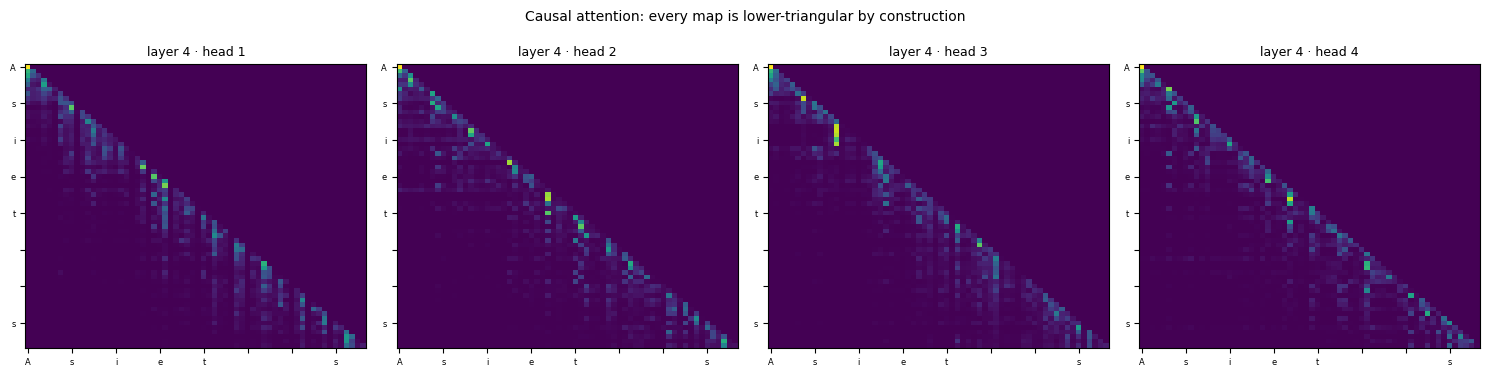

Rows are queries, columns are keys. The upper triangle is exactly zero in
every head — that is the causal mask, and it is what makes parallel training
of an autoregressive model possible.

head 1: final position attends most to 's' (0.36), 't' (0.23), 'r' (0.08)
head 2: final position attends most to 't' (0.44), 'b' (0.08), 's' (0.06)
head 3: final position attends most to 's' (0.21), 'r' (0.11), 's' (0.11)
head 4: final position attends most to 's' (0.31), 's' (0.16), 't' (0.14)


In [14]:
sample = 'Alice was beginning to get very tired of sitting by her sister'
ids = torch.tensor([encode(sample)], dtype=torch.long, device=device)

model.eval()
with torch.no_grad():
    _, _, attns = model(ids, return_attn=True)

layer = -1                        # the last block
att = attns[layer][0].cpu()       # (n_head, T, T)
T = att.shape[-1]

fig, axes = plt.subplots(1, att.shape[0], figsize=(15, 3.8))
for h, ax in enumerate(axes):
    ax.imshow(att[h], cmap='viridis', aspect='auto')
    ax.set_title(f'layer {len(attns)} · head {h + 1}', fontsize=9)
    ticks = range(0, T, 8)
    ax.set_xticks(ticks); ax.set_yticks(ticks)
    ax.set_xticklabels([sample[i] for i in ticks], fontsize=6)
    ax.set_yticklabels([sample[i] for i in ticks], fontsize=6)
plt.suptitle('Causal attention: every map is lower-triangular by construction', fontsize=10)
plt.tight_layout(); plt.show()

print('Rows are queries, columns are keys. The upper triangle is exactly zero in')
print('every head — that is the causal mask, and it is what makes parallel training')
print('of an autoregressive model possible.')
print()
for h in range(att.shape[0]):
    last = att[h, -1]
    top = torch.topk(last, 3)
    picks = ', '.join(f'{repr(sample[i])} ({w:.2f})' for w, i in zip(top.values, top.indices))
    print(f'head {h+1}: final position attends most to {picks}')

---
## Step 11: The Same Thing, With the Library

You have now written causal attention twice — once as a matrix of scores, once with a
cache. Production code writes it in one line:

```python
out = F.scaled_dot_product_attention(q, k, v, is_causal=True)
```

Two questions worth answering with code rather than trust: **is it the same
function?**, and **what does it buy?** The first is a numerical check. The second is a
measurement.

This is the pattern to apply to every library you adopt: reproduce it by hand once,
assert equivalence, then measure the gap. After that you can use the fast path knowing
exactly what it does — and, more importantly, debug it when it misbehaves.

In [15]:
torch.manual_seed(0)
B, H, L, Dk = 2, 4, 64, 32
q = torch.randn(B, H, L, Dk, device=device)
k = torch.randn(B, H, L, Dk, device=device)
v = torch.randn(B, H, L, Dk, device=device)

# --- ours, exactly as written in Step 4 -----------------------------------------
mask = torch.triu(torch.ones(L, L, dtype=torch.bool, device=device), diagonal=1)
att = (q @ k.transpose(-2, -1)) / math.sqrt(Dk)
att = F.softmax(att.masked_fill(mask, float('-inf')), dim=-1)
ours = att @ v

# --- PyTorch's fused version -----------------------------------------------------
theirs = F.scaled_dot_product_attention(q, k, v, is_causal=True)

diff = (ours - theirs).abs().max().item()
print(f'max absolute difference : {diff:.3e}')
print(f'allclose (atol=1e-5)    : {torch.allclose(ours, theirs, atol=1e-5)}')
print()
print('Identical to floating-point tolerance. It is the same mathematics — the')
print('difference is entirely in how the computation is scheduled.')

max absolute difference : 4.768e-07
allclose (atol=1e-5)    : True

Identical to floating-point tolerance. It is the same mathematics — the
difference is entirely in how the computation is scheduled.


In [16]:
# What it buys: the explicit version must MATERIALISE the (B, H, L, L) score matrix.
# The fused version computes attention in tiles and never allocates it.
print(f'{"L":>7} {"score matrix":>14} {"q/k/v total":>13} {"ratio":>8}')
for L_ in (128, 512, 2048, 8192, 32768):
    scores = B * H * L_ * L_ * 4          # bytes, fp32
    qkv = 3 * B * H * L_ * Dk * 4
    print(f'{L_:>7} {scores/1e9:>11.2f} GB {qkv/1e9:>10.3f} GB {scores/qkv:>8.0f}x')

print()
print('At L=32768 the score matrix alone is far beyond this machine, while q, k and v')
print('together are under a gigabyte. Attention is not inherently quadratic in MEMORY —')
print('only the naive implementation is. That distinction is what FlashAttention')
print('exploits, and it is why long-context models became possible without any change')
print('to the mathematics you implemented in Step 4.')

      L   score matrix   q/k/v total    ratio
    128        0.00 GB      0.000 GB        1x
    512        0.01 GB      0.002 GB        5x
   2048        0.13 GB      0.006 GB       21x
   8192        2.15 GB      0.025 GB       85x
  32768       34.36 GB      0.101 GB      341x

At L=32768 the score matrix alone is far beyond this machine, while q, k and v
together are under a gigabyte. Attention is not inherently quadratic in MEMORY —
only the naive implementation is. That distinction is what FlashAttention
exploits, and it is why long-context models became possible without any change
to the mathematics you implemented in Step 4.


In [17]:
def timed_call(fn, warmup=5, n=30):
    """Report the MINIMUM of n runs after a warmup — far less noise-sensitive
    than the mean, which on a laptop is dominated by scheduling."""
    for _ in range(warmup):
        fn()
    if device.type == 'mps':
        torch.mps.synchronize()
    times = []
    for _ in range(n):
        t = time.time()
        fn()
        if device.type == 'mps':
            torch.mps.synchronize()
        times.append(time.time() - t)
    return min(times) * 1000     # ms


print(f'{"L":>6} {"explicit (ms)":>15} {"fused (ms)":>12} {"ratio":>8}')
for L_ in (128, 256, 512, 1024, 2048):
    qq = torch.randn(B, H, L_, Dk, device=device)
    kk = torch.randn(B, H, L_, Dk, device=device)
    vv = torch.randn(B, H, L_, Dk, device=device)
    m = torch.triu(torch.ones(L_, L_, dtype=torch.bool, device=device), diagonal=1)

    def explicit():
        a = (qq @ kk.transpose(-2, -1)) / math.sqrt(Dk)
        a = F.softmax(a.masked_fill(m, float('-inf')), dim=-1)
        return a @ vv

    fused = lambda: F.scaled_dot_product_attention(qq, kk, vv, is_causal=True)

    te, tf = timed_call(explicit), timed_call(fused)
    print(f'{L_:>6} {te:>15.3f} {tf:>12.3f} {te/tf:>7.2f}x')

print()
print('Read this cautiously: on this backend the ratio is close to 1 and does not')
print('trend cleanly, so the honest conclusion is that the fused path is NOT')
print('measurably faster here. Two reasons, both worth knowing:')
print()
print('  1. PyTorch dispatches scaled_dot_product_attention to one of several')
print('     kernels. The FlashAttention backend is CUDA-only; on MPS you get a')
print('     math or memory-efficient fallback, which is the same arithmetic with')
print('     less aggressive fusion.')
print('  2. At these sizes the whole operation is launch-bound, so both versions')
print('     are measuring overhead rather than arithmetic.')
print()
print('The MEMORY argument in the previous cell holds regardless of backend, and')
print('it is the one that actually changed what models are possible. This is a')
print('useful habit generally: when a library claims a speedup, check whether the')
print('fast path is even available on your hardware before you attribute anything')
print('to it.')

     L   explicit (ms)   fused (ms)    ratio
   128           0.559        0.286    1.96x


   256           0.442        0.384    1.15x


   512           1.151        1.120    1.03x


  1024           3.427        3.712    0.92x


  2048          12.930       13.297    0.97x

Read this cautiously: on this backend the ratio is close to 1 and does not
trend cleanly, so the honest conclusion is that the fused path is NOT
measurably faster here. Two reasons, both worth knowing:

  1. PyTorch dispatches scaled_dot_product_attention to one of several
     kernels. The FlashAttention backend is CUDA-only; on MPS you get a
     math or memory-efficient fallback, which is the same arithmetic with
     less aggressive fusion.
  2. At these sizes the whole operation is launch-bound, so both versions
     are measuring overhead rather than arithmetic.

The MEMORY argument in the previous cell holds regardless of backend, and
it is the one that actually changed what models are possible. This is a
useful habit generally: when a library claims a speedup, check whether the
fast path is even available on your hardware before you attribute anything
to it.


### And the block, and the model

The same substitution applies one level up. Your `Block` is `nn.TransformerEncoderLayer`
with `norm_first=True`; a whole GPT is a few lines of `transformers`:

```python
# PyTorch, one block
layer = nn.TransformerEncoderLayer(d_model=128, nhead=4, dim_feedforward=512,
                                   norm_first=True,      # your pre-norm
                                   batch_first=True, activation='gelu')

# HuggingFace, the whole model
from transformers import GPT2Config, GPT2LMHeadModel
model = GPT2LMHeadModel(GPT2Config(n_embd=768, n_head=12, n_layer=12))
out = model(input_ids, labels=input_ids)   # .loss already does your shift
model.generate(ids, do_sample=True, temperature=0.8, top_p=0.9, use_cache=True)
```

Map those arguments onto what you built: `norm_first` is the pre-norm ordering from
Step 5, `labels=` is the one-token shift from Step 3, `use_cache` is your
`CachedAttention`, and `top_p` is the nucleus sampling from Step 8. **GPT-2 is this
notebook at 124M parameters.**

The library is the right choice for real work — it handles batched generation, stopping
criteria, quantized loading, and the cache edge cases yours asserts its way out of. The
reason to have built it once anyway is that every one of those arguments is now a thing
you understand rather than a thing you copy.

---
### Concept Check: Generation

1. Why must the generation loop crop its input to the last `block_size` tokens?
   What would a longer prompt do?
2. Top-k and top-p both truncate the candidate pool. Give a concrete situation
   where top-p behaves better than top-k.
3. The KV cache stores keys and values but not queries. Why is there nothing to
   cache on the query side?

In [18]:
# 1. pos_emb is an nn.Embedding(block_size, n_embd) — there is literally no
#    embedding vector for position block_size or beyond. A longer input would
#    index out of bounds and raise. (The forward pass also asserts on it.) This
#    is the hard context limit of a learned-position model, and it is why
#    extending a trained model's context window is a research problem rather
#    than a config change.
#
# 2. Consider two steps: after "the" the model is genuinely uncertain across 40
#    plausible nouns; after "Alice was beginning t" it is ~99% sure the next
#    character is "o". Top-k=40 keeps 40 candidates in both cases — reasonable in
#    the first, and in the second it admits 39 characters the model considers
#    nearly impossible. Top-p=0.9 keeps ~40 candidates in the first case and
#    exactly 1 in the second. The pool adapts to the model's actual confidence.
#
# 3. The query is a property of the *current* token only, and each step has a new
#    current token, so there is nothing from previous steps to reuse. Keys and
#    values, by contrast, are properties of past tokens — and because the causal
#    mask guarantees a past token's representation never depends on future ones,
#    they are provably unchanged and safe to reuse.

---
## What You Built

- **Causal self-attention** with a registered mask buffer
- A **pre-norm block** — the GPT-2 arrangement, contrasted with lesson 07's post-norm
- A **GPT** with learned positional embeddings, tied weights, and depth-scaled init
- Training with **warmup + cosine decay** and **AdamW** with selective weight decay
- **Temperature, top-k, and nucleus sampling**, compared side by side
- A **KV cache**, with an honest wall-clock measurement and an operation count
- The **library equivalent**, verified numerically against your own implementation

You now have every component of a modern language model. The only differences
between this and a frontier model are scale, data, a subword tokenizer, and
post-training — not architecture.

## Next

[Lesson 11](../11_quantization_and_lora/prompt.ipynb) attacks the resource problem
directly: quantizing these weights to 8 and 4 bits, and fine-tuning with LoRA using
a fraction of a percent of the parameters. Both are implemented from scratch on the
model you just trained.